In [3]:
# Reddit Dataset Analysis
import json
import os
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Explore Basic Structure
def load_json_file(file_path):
    """Load a single JSON file and return its contents"""
    with open(file_path, 'r') as f:
        return json.load(f)

# Set your data directory
DATA_DIR = "reddit_leaf/train/"
sample_file = os.path.join(DATA_DIR, "reddit_0_train.json")


In [4]:
# Load one file for initial analysis
data = load_json_file(sample_file)

# Basic structure analysis
print("Top level keys:", list(data.keys()))
print("Number of users:", len(data['user_data']))

Top level keys: ['users', 'num_samples', 'user_data']
Number of users: 81726


In [12]:
# 2. Analyze Single User Structure
# Get first user data
first_user_id = list(data['user_data'].keys())[0]
first_user_data = data['user_data'][first_user_id]

print("\nUser data structure:")
print("Keys in user data:", list(first_user_data.keys()))
print("Number of sequences:", len(first_user_data['x']))


User data structure:
Keys in user data: ['x', 'y']
Number of sequences: 30


In [13]:
# 3. Analyze Sequence Structure
first_sequence = first_user_data['x'][0]
print("\nSequence structure:")
print("Type of sequence:", type(first_sequence))
print("Length of first sequence:", len(first_sequence))
print("Type of first element:", type(first_sequence[0]))


Sequence structure:
Type of sequence: <class 'list'>
Length of first sequence: 1
Type of first element: <class 'list'>


In [16]:
first_sequence

[['<BOS>',
  '1',
  'channel',
  'and',
  'never',
  'anything',
  'on',
  '<EOS>',
  '<PAD>',
  '<PAD>']]


User Statistics:
Average sequences per user: 20.13
Average tokens per user: 878.48

Sequence Statistics:
Average sequence length: 4.36
Average inner sequence length: 10.00

Token Statistics:
Total unique tokens: 532719

Most common tokens:
<PAD>: 7136211
.: 2992447
the: 2069863
,: 1861980
<BOS>: 1645093
<EOS>: 1645093
to: 1383297
a: 1284650
i: 1142525
and: 1115984


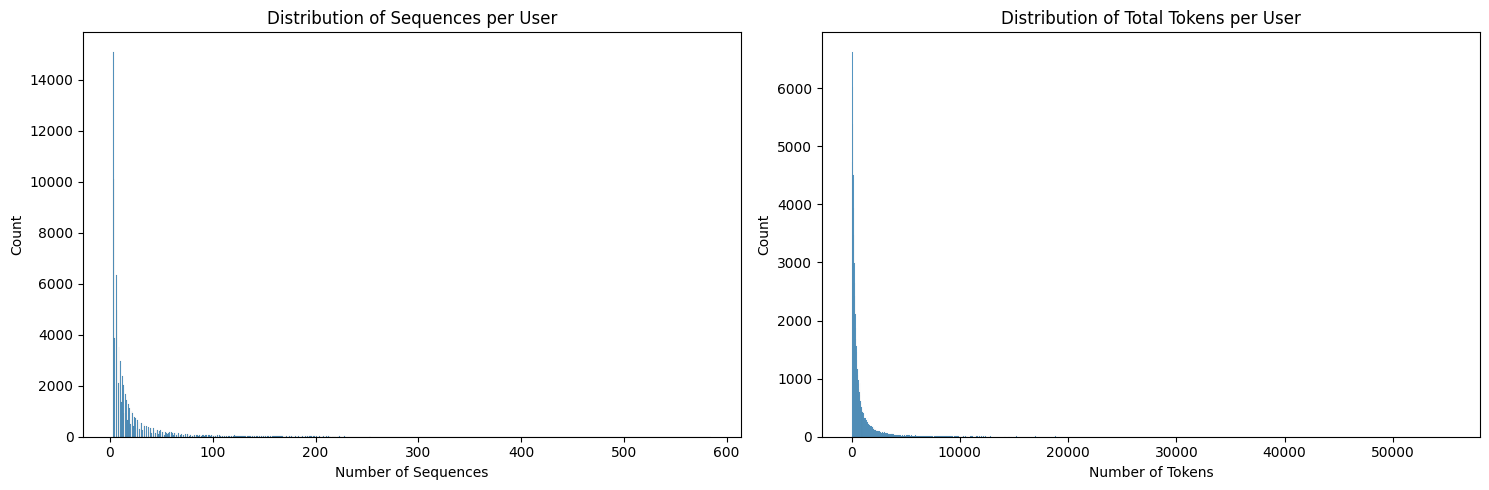

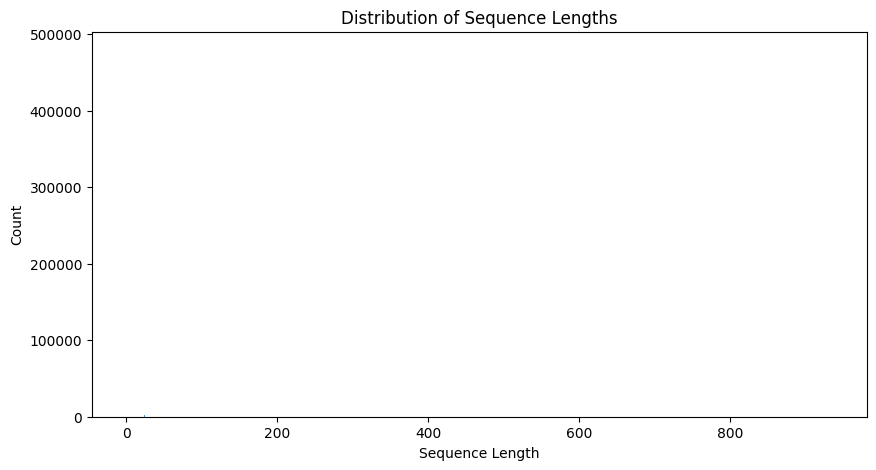

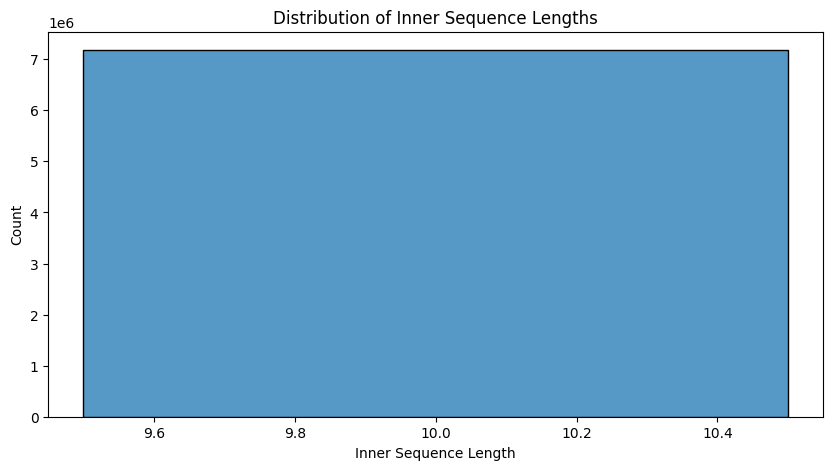

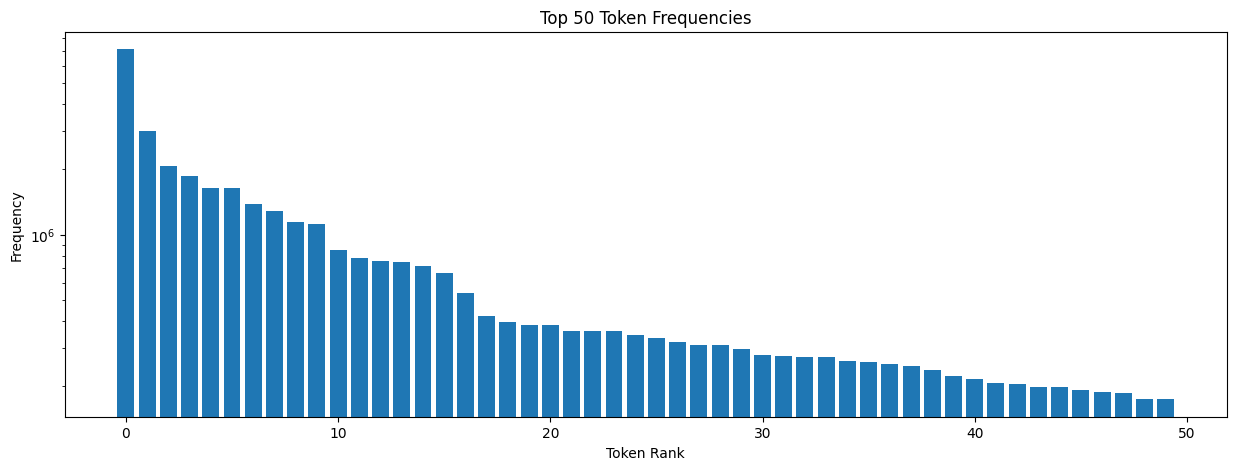

In [17]:
# 4. Detailed Data Analysis Functions
def analyze_user_statistics(data):
    """Analyze user-level statistics"""
    user_stats = {
        'sequence_counts': [],
        'total_tokens': []
    }
    
    for user_id, user_data in data['user_data'].items():
        sequences = user_data['x']
        user_stats['sequence_counts'].append(len(sequences))
        
        # Count total tokens for user
        token_count = 0
        for seq in sequences:
            if isinstance(seq[0], list):  # Handle nested lists
                for inner_seq in seq:
                    token_count += len(inner_seq)
            else:
                token_count += len(seq)
        user_stats['total_tokens'].append(token_count)
    
    return user_stats

def analyze_sequence_statistics(data):
    """Analyze sequence-level statistics"""
    sequence_stats = {
        'outer_lengths': [],
        'inner_lengths': [] if isinstance(next(iter(data['user_data'].values()))['x'][0][0], list) else None
    }
    
    for user_data in data['user_data'].values():
        for seq in user_data['x']:
            sequence_stats['outer_lengths'].append(len(seq))
            
            if sequence_stats['inner_lengths'] is not None:
                for inner_seq in seq:
                    sequence_stats['inner_lengths'].append(len(inner_seq))
    
    return sequence_stats

def analyze_token_distribution(data):
    """Analyze token distribution"""
    token_counter = collections.Counter()
    
    for user_data in data['user_data'].values():
        for seq in user_data['x']:
            if isinstance(seq[0], list):  # Handle nested lists
                for inner_seq in seq:
                    token_counter.update(inner_seq)
            else:
                token_counter.update(seq)
    
    return token_counter

# 5. Visualization Functions
def plot_user_statistics(user_stats):
    """Plot user-level statistics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Sequence count distribution
    sns.histplot(user_stats['sequence_counts'], ax=ax1)
    ax1.set_title('Distribution of Sequences per User')
    ax1.set_xlabel('Number of Sequences')
    
    # Token count distribution
    sns.histplot(user_stats['total_tokens'], ax=ax2)
    ax2.set_title('Distribution of Total Tokens per User')
    ax2.set_xlabel('Number of Tokens')
    
    plt.tight_layout()
    plt.show()

def plot_sequence_statistics(sequence_stats):
    """Plot sequence-level statistics"""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.histplot(sequence_stats['outer_lengths'], ax=ax)
    ax.set_title('Distribution of Sequence Lengths')
    ax.set_xlabel('Sequence Length')
    
    if sequence_stats['inner_lengths']:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.histplot(sequence_stats['inner_lengths'], ax=ax)
        ax.set_title('Distribution of Inner Sequence Lengths')
        ax.set_xlabel('Inner Sequence Length')
    
    plt.show()

def plot_token_distribution(token_counter, top_n=50):
    """Plot token frequency distribution"""
    most_common = token_counter.most_common(top_n)
    tokens, counts = zip(*most_common)
    
    plt.figure(figsize=(15, 5))
    plt.bar(range(len(counts)), counts)
    plt.title(f'Top {top_n} Token Frequencies')
    plt.xlabel('Token Rank')
    plt.ylabel('Frequency')
    plt.yscale('log')
    plt.show()

# 6. Run Analysis
# Analyze user statistics
user_stats = analyze_user_statistics(data)
print("\nUser Statistics:")
print(f"Average sequences per user: {np.mean(user_stats['sequence_counts']):.2f}")
print(f"Average tokens per user: {np.mean(user_stats['total_tokens']):.2f}")

# Analyze sequence statistics
sequence_stats = analyze_sequence_statistics(data)
print("\nSequence Statistics:")
print(f"Average sequence length: {np.mean(sequence_stats['outer_lengths']):.2f}")
if sequence_stats['inner_lengths']:
    print(f"Average inner sequence length: {np.mean(sequence_stats['inner_lengths']):.2f}")

# Analyze token distribution
token_counter = analyze_token_distribution(data)
print("\nToken Statistics:")
print(f"Total unique tokens: {len(token_counter)}")
print("\nMost common tokens:")
for token, count in token_counter.most_common(10):
    print(f"{token}: {count}")

# Generate visualizations
plot_user_statistics(user_stats)
plot_sequence_statistics(sequence_stats)
plot_token_distribution(token_counter)

In [ ]:
# 7. Multi-file Analysis
def analyze_multiple_files(data_dir):
    """Analyze statistics across multiple files"""
    file_stats = []
    
    for filename in sorted(os.listdir(data_dir)):
        if filename.endswith('.json'):
            file_path = os.path.join(data_dir, filename)
            data = load_json_file(file_path)
            
            stats = {
                'filename': filename,
                'num_users': len(data['user_data']),
                'total_sequences': sum(len(user_data['x']) for user_data in data['user_data'].values())
            }
            file_stats.append(stats)
    
    return pd.DataFrame(file_stats)

# Run multi-file analysis
file_stats_df = analyze_multiple_files(DATA_DIR)
print("\nFile Statistics:")
print(file_stats_df)

# Plot file statistics
plt.figure(figsize=(12, 5))
plt.bar(range(len(file_stats_df)), file_stats_df['total_sequences'])
plt.title('Sequences per File')
plt.xlabel('File Index')
plt.ylabel('Number of Sequences')
plt.show()

Sequence Length Statistics:
Total sequences analyzed: 7179463

Original Sequence Lengths (including PAD):
Mean: 10.00
Median: 10.00
Min: 10
Max: 10
95th percentile: 10.00

Actual Sequence Lengths (until EOS):
Mean: 9.01
Median: 10.00
Min: 1
Max: 10
95th percentile: 10.00

PAD Token Statistics:
Mean PADs per sequence: 0.99
Max PADs in a sequence: 9
Sequences with PAD: 1469536
Sequences without PAD: 5709927

Token Consistency Check:
Sequences starting with BOS: 1645093/7179463 (22.91%)
Sequences with EOS followed by only PAD: 1469536/7179463 (20.47%)
Sequences with multiple BOS: 0
Sequences with multiple EOS: 0


/tmp/ipykernel_2102183/3003142136.py:76: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(positions, ax=ax4, label=token)


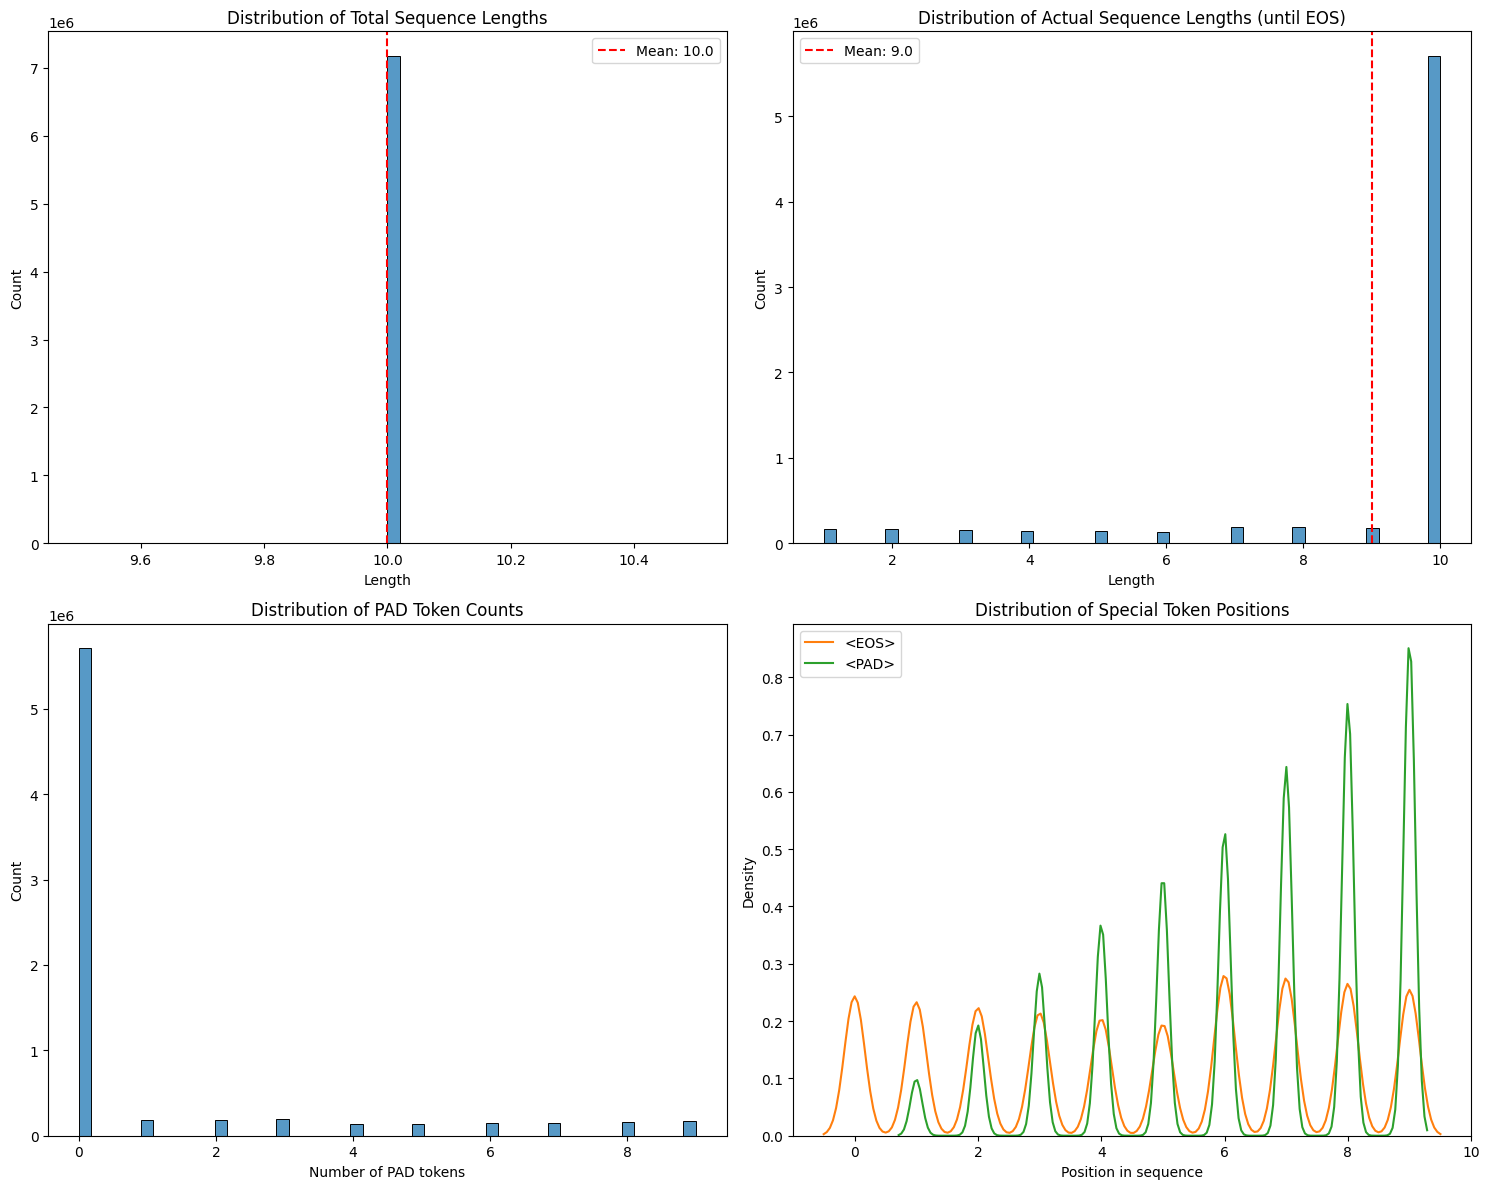

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

def analyze_sequence_lengths_and_special_tokens(data):
    """
    Analyze sequence lengths and special tokens in the dataset
    """
    # Track statistics
    sequence_lengths = []  # Original sequence lengths (including PAD)
    actual_lengths = []    # Lengths until EOS or end of sequence
    special_token_positions = defaultdict(list)  # Position of special tokens
    pad_counts = []        # Number of PAD tokens per sequence
    
    for user_id, user_data in data['user_data'].items():
        for sequence_list in user_data['x']:
            for sequence in sequence_list:
                # Store original length
                seq_len = len(sequence)
                sequence_lengths.append(seq_len)
                
                # Count PAD tokens
                pad_count = sequence.count('<PAD>')
                pad_counts.append(pad_count)
                
                # Find actual length (until EOS or end)
                try:
                    eos_pos = sequence.index('<EOS>')
                    actual_lengths.append(eos_pos + 1)  # +1 to include EOS
                except ValueError:
                    actual_lengths.append(seq_len)
                
                # Track special token positions
                for i, token in enumerate(sequence):
                    if token in ['<BOS>', '<EOS>', '<PAD>']:
                        special_token_positions[token].append(i)
    
    return {
        'sequence_lengths': sequence_lengths,
        'actual_lengths': actual_lengths,
        'special_token_positions': special_token_positions,
        'pad_counts': pad_counts
    }

def plot_length_distributions(stats):
    """
    Plot various length-related distributions
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Original sequence lengths
    sns.histplot(stats['sequence_lengths'], ax=ax1, bins=50)
    ax1.set_title('Distribution of Total Sequence Lengths')
    ax1.set_xlabel('Length')
    ax1.axvline(np.mean(stats['sequence_lengths']), color='r', linestyle='--', 
                label=f'Mean: {np.mean(stats["sequence_lengths"]):.1f}')
    ax1.legend()
    
    # Actual lengths (until EOS)
    sns.histplot(stats['actual_lengths'], ax=ax2, bins=50)
    ax2.set_title('Distribution of Actual Sequence Lengths (until EOS)')
    ax2.set_xlabel('Length')
    ax2.axvline(np.mean(stats['actual_lengths']), color='r', linestyle='--',
                label=f'Mean: {np.mean(stats["actual_lengths"]):.1f}')
    ax2.legend()
    
    # PAD token counts
    sns.histplot(stats['pad_counts'], ax=ax3, bins=50)
    ax3.set_title('Distribution of PAD Token Counts')
    ax3.set_xlabel('Number of PAD tokens')
    
    # Special token positions
    for token, positions in stats['special_token_positions'].items():
        sns.kdeplot(positions, ax=ax4, label=token)
    ax4.set_title('Distribution of Special Token Positions')
    ax4.set_xlabel('Position in sequence')
    ax4.legend()
    
    plt.tight_layout()
    return fig

def print_sequence_statistics(stats):
    """
    Print detailed statistics about sequences
    """
    print("Sequence Length Statistics:")
    print(f"Total sequences analyzed: {len(stats['sequence_lengths'])}")
    print("\nOriginal Sequence Lengths (including PAD):")
    print(f"Mean: {np.mean(stats['sequence_lengths']):.2f}")
    print(f"Median: {np.median(stats['sequence_lengths']):.2f}")
    print(f"Min: {min(stats['sequence_lengths'])}")
    print(f"Max: {max(stats['sequence_lengths'])}")
    print(f"95th percentile: {np.percentile(stats['sequence_lengths'], 95):.2f}")
    
    print("\nActual Sequence Lengths (until EOS):")
    print(f"Mean: {np.mean(stats['actual_lengths']):.2f}")
    print(f"Median: {np.median(stats['actual_lengths']):.2f}")
    print(f"Min: {min(stats['actual_lengths'])}")
    print(f"Max: {max(stats['actual_lengths'])}")
    print(f"95th percentile: {np.percentile(stats['actual_lengths'], 95):.2f}")
    
    print("\nPAD Token Statistics:")
    print(f"Mean PADs per sequence: {np.mean(stats['pad_counts']):.2f}")
    print(f"Max PADs in a sequence: {max(stats['pad_counts'])}")
    print(f"Sequences with PAD: {sum(1 for x in stats['pad_counts'] if x > 0)}")
    print(f"Sequences without PAD: {sum(1 for x in stats['pad_counts'] if x == 0)}")

def analyze_token_consistency(data):
    """
    Analyze consistency of special token usage
    """
    bos_start = 0
    eos_followed_by_pad = 0
    multiple_bos = 0
    multiple_eos = 0
    total_sequences = 0
    
    for user_id, user_data in data['user_data'].items():
        for sequence_list in user_data['x']:
            for sequence in sequence_list:
                total_sequences += 1
                
                # Check BOS position
                if sequence[0] == '<BOS>':
                    bos_start += 1
                
                # Check multiple special tokens
                bos_count = sequence.count('<BOS>')
                eos_count = sequence.count('<EOS>')
                
                if bos_count > 1:
                    multiple_bos += 1
                if eos_count > 1:
                    multiple_eos += 1
                
                # Check if EOS is followed by PAD
                try:
                    eos_idx = sequence.index('<EOS>')
                    if eos_idx < len(sequence) - 1 and all(t == '<PAD>' for t in sequence[eos_idx + 1:]):
                        eos_followed_by_pad += 1
                except ValueError:
                    continue
    
    print("\nToken Consistency Check:")
    print(f"Sequences starting with BOS: {bos_start}/{total_sequences} ({bos_start/total_sequences*100:.2f}%)")
    print(f"Sequences with EOS followed by only PAD: {eos_followed_by_pad}/{total_sequences} ({eos_followed_by_pad/total_sequences*100:.2f}%)")
    print(f"Sequences with multiple BOS: {multiple_bos}")
    print(f"Sequences with multiple EOS: {multiple_eos}")

# Usage example:
DATA_PATH = "reddit_leaf/train/reddit_0_train.json"
with open(DATA_PATH, 'r') as f:
    data = json.load(f)

# Run analyses
stats = analyze_sequence_lengths_and_special_tokens(data)
print_sequence_statistics(stats)
analyze_token_consistency(data)
plot_length_distributions(stats)
plt.show()

Total sequences analyzed: 7,179,463
Sequences truncated: 5,646,943 (78.65%)
Total tokens lost: 9,794,940
Average tokens lost per truncated sequence: 1.73

Content Length Statistics (excluding special tokens):
Mean: 8.55
Median: 10.00
95th percentile: 10.00
Max: 10


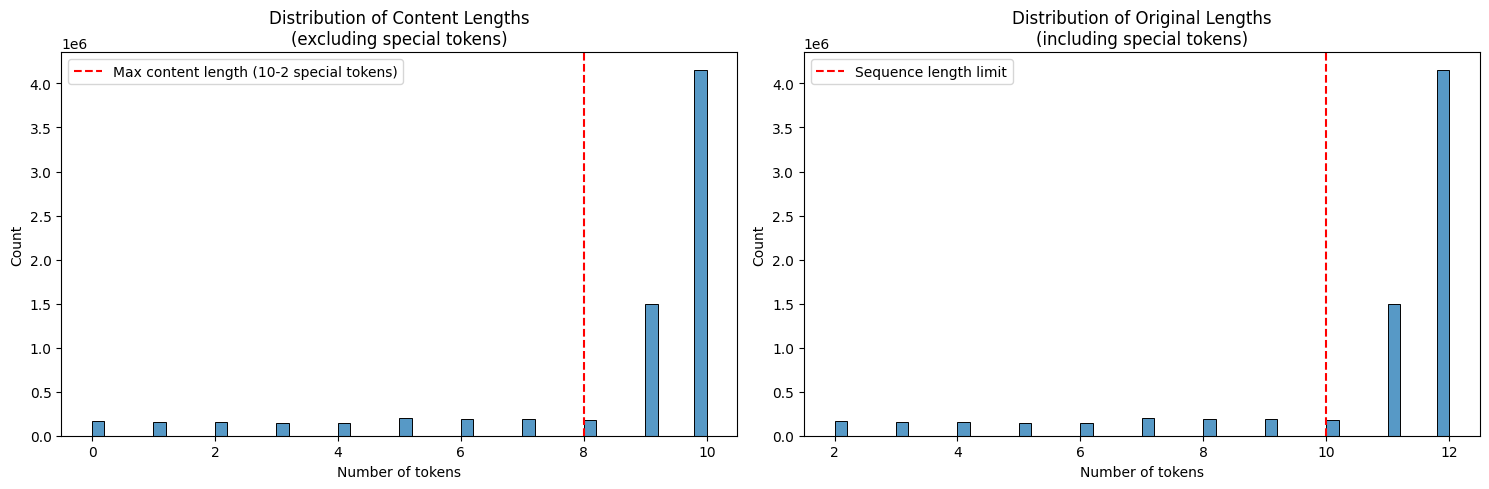

In [22]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_truncation(data_path):
    """
    Analyze how many sequences are being truncated by the 10-token limit
    """
    with open(data_path, 'r') as f:
        data = json.load(f)
    
    # Track lengths
    original_lengths = []  # Length including BOS and EOS
    content_lengths = []   # Length of actual content (without special tokens)
    truncated_sequences = 0
    total_sequences = 0
    lost_tokens = 0  # Track how many tokens are being cut off
    
    for user_id, user_data in data['user_data'].items():
        for sequence_list in user_data['x']:
            for sequence in sequence_list:
                total_sequences += 1
                
                # Get content tokens (exclude BOS, EOS, PAD)
                content_tokens = [t for t in sequence if t not in ['<BOS>', '<EOS>', '<PAD>']]
                content_length = len(content_tokens)
                content_lengths.append(content_length)
                
                # Calculate original length (content + BOS + EOS)
                original_length = content_length + 2  # +2 for BOS and EOS
                original_lengths.append(original_length)
                
                # Check if sequence would be truncated
                if original_length > 10:
                    truncated_sequences += 1
                    lost_tokens += original_length - 10
    
    # Calculate statistics
    stats = {
        'total_sequences': total_sequences,
        'truncated_sequences': truncated_sequences,
        'truncation_percentage': (truncated_sequences / total_sequences) * 100,
        'lost_tokens': lost_tokens,
        'avg_lost_tokens_per_truncation': lost_tokens / truncated_sequences if truncated_sequences > 0 else 0,
        'content_lengths': content_lengths,
        'original_lengths': original_lengths
    }
    
    # Print results
    print(f"Total sequences analyzed: {stats['total_sequences']:,}")
    print(f"Sequences truncated: {stats['truncated_sequences']:,} ({stats['truncation_percentage']:.2f}%)")
    print(f"Total tokens lost: {stats['lost_tokens']:,}")
    print(f"Average tokens lost per truncated sequence: {stats['avg_lost_tokens_per_truncation']:.2f}")
    
    print("\nContent Length Statistics (excluding special tokens):")
    print(f"Mean: {np.mean(content_lengths):.2f}")
    print(f"Median: {np.median(content_lengths):.2f}")
    print(f"95th percentile: {np.percentile(content_lengths, 95):.2f}")
    print(f"Max: {max(content_lengths)}")
    
    # Create visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Content length distribution
    sns.histplot(content_lengths, bins=50, ax=ax1)
    ax1.axvline(x=8, color='r', linestyle='--', label='Max content length (10-2 special tokens)')
    ax1.set_title('Distribution of Content Lengths\n(excluding special tokens)')
    ax1.set_xlabel('Number of tokens')
    ax1.legend()
    
    # Original length distribution
    sns.histplot(original_lengths, bins=50, ax=ax2)
    ax2.axvline(x=10, color='r', linestyle='--', label='Sequence length limit')
    ax2.set_title('Distribution of Original Lengths\n(including special tokens)')
    ax2.set_xlabel('Number of tokens')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return stats

# Usage example:
DATA_PATH = "reddit_leaf/train/reddit_0_train.json"
truncation_stats = analyze_truncation(DATA_PATH)

In [23]:
import json
import os
from collections import defaultdict

def count_samples(file_path):
    """Count samples and sequences in a single file"""
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    file_stats = {
        'total_users': len(data['user_data']),
        'total_sequences': 0,
        'sequences_per_user': defaultdict(int)
    }
    
    for user_id, user_data in data['user_data'].items():
        num_sequences = len(user_data['x'])
        file_stats['total_sequences'] += num_sequences
        file_stats['sequences_per_user'][user_id] = num_sequences
    
    return file_stats

def analyze_all_files(base_dir):
    """Analyze all training files"""
    total_stats = {
        'files': [],
        'total_users': 0,
        'total_sequences': 0,
        'unique_users': set()
    }
    
    # Process files from reddit_0_train.json to reddit_20_train.json
    for i in range(21):  # 0 to 20 inclusive
        filename = f'reddit_{i}_train.json'
        file_path = os.path.join(base_dir, 'train', filename)
        
        if not os.path.exists(file_path):
            print(f"Warning: File {filename} not found")
            continue
            
        print(f"Processing {filename}...")
        stats = count_samples(file_path)
        
        file_info = {
            'filename': filename,
            'num_users': stats['total_users'],
            'num_sequences': stats['total_sequences'],
            'avg_sequences_per_user': stats['total_sequences'] / stats['total_users'] if stats['total_users'] > 0 else 0
        }
        
        total_stats['files'].append(file_info)
        total_stats['total_sequences'] += stats['total_sequences']
        total_stats['unique_users'].update(stats['sequences_per_user'].keys())
        
    total_stats['total_users'] = len(total_stats['unique_users'])
    
    # Print results
    print("\nDetailed Analysis:")
    print("-" * 80)
    print(f"{'Filename':<20} {'Users':<10} {'Sequences':<12} {'Avg Seq/User':<15}")
    print("-" * 80)
    
    for file_info in total_stats['files']:
        print(f"{file_info['filename']:<20} {file_info['num_users']:<10} {file_info['num_sequences']:<12} {file_info['avg_sequences_per_user']:.2f}")
    
    print("-" * 80)
    print(f"\nOverall Statistics:")
    print(f"Total unique users: {total_stats['total_users']:,}")
    print(f"Total sequences: {total_stats['total_sequences']:,}")
    print(f"Average sequences per file: {total_stats['total_sequences'] / len(total_stats['files']):,.2f}")
    print(f"Average sequences per user: {total_stats['total_sequences'] / total_stats['total_users']:,.2f}")
    
    return total_stats

# Usage example:
DATA_DIR = "reddit_leaf"
total_stats = analyze_all_files(DATA_DIR)

Processing reddit_0_train.json...
Processing reddit_1_train.json...
Processing reddit_2_train.json...
Processing reddit_3_train.json...
Processing reddit_4_train.json...
Processing reddit_5_train.json...
Processing reddit_6_train.json...
Processing reddit_7_train.json...
Processing reddit_8_train.json...
Processing reddit_9_train.json...
Processing reddit_10_train.json...
Processing reddit_11_train.json...
Processing reddit_12_train.json...
Processing reddit_13_train.json...
Processing reddit_14_train.json...
Processing reddit_15_train.json...
Processing reddit_16_train.json...
Processing reddit_17_train.json...
Processing reddit_18_train.json...
Processing reddit_19_train.json...
Processing reddit_20_train.json...

Detailed Analysis:
--------------------------------------------------------------------------------
Filename             Users      Sequences    Avg Seq/User   
--------------------------------------------------------------------------------
reddit_0_train.json  81726      

## Vocab file analysis

In [1]:
# Import necessary libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load the vocabulary file
with open('reddit_vocab.pck', 'rb') as f:
    vocab_dict = pickle.load(f)

In [2]:
# 1. Basic information about the vocabulary
print("=== Basic Vocabulary Information ===")
print(f"Type of loaded data: {type(vocab_dict)}")
print(f"Keys in vocab_dict: {vocab_dict.keys()}")

=== Basic Vocabulary Information ===
Type of loaded data: <class 'dict'>
Keys in vocab_dict: dict_keys(['vocab', 'size', 'pad_symbol', 'unk_symbol'])


In [3]:
# 2. Analyze the vocabulary dictionary
vocab = vocab_dict['vocab']
pad_symbol = vocab_dict['pad_symbol']
unk_symbol = vocab_dict['unk_symbol']

print("\n=== Vocabulary Statistics ===")
print(f"Vocabulary size: {len(vocab)}")
print(f"PAD symbol index: {pad_symbol}")
print(f"UNK symbol index: {unk_symbol}")


=== Vocabulary Statistics ===
Vocabulary size: 10000
PAD symbol index: 0
UNK symbol index: 1


In [5]:
# 3. Check for index bounds
vocab_indices = list(vocab.values())
min_index = min(vocab_indices)
max_index = max(vocab_indices)

print("\n=== Index Analysis ===")
print(f"Minimum index in vocab: {min_index}")
print(f"Maximum index in vocab: {max_index}")
print(f"Index range: {max_index - min_index + 1}")


=== Index Analysis ===
Minimum index in vocab: 0
Maximum index in vocab: 10000
Index range: 10001


In [6]:
# 4. Check for potential issues
print("\n=== Potential Issues ===")

# Check if PAD or UNK symbols are out of bounds
print(f"Is PAD symbol index >= vocab size? {pad_symbol >= len(vocab)}")
print(f"Is UNK symbol index >= vocab size? {unk_symbol >= len(vocab)}")

# Check for index gaps
sorted_indices = sorted(vocab_indices)
expected_indices = set(range(min_index, max_index + 1))
actual_indices = set(sorted_indices)
missing_indices = expected_indices - actual_indices

print(f"\nMissing indices in vocabulary: {missing_indices}")


=== Potential Issues ===
Is PAD symbol index >= vocab size? False
Is UNK symbol index >= vocab size? False

Missing indices in vocabulary: {2}


In [7]:

# Find token with maximum index
max_index_token = [token for token, idx in vocab.items() if idx == max_index]
print(f"\nToken(s) with maximum index {max_index}: {max_index_token}")

# Check for duplicate indices
duplicate_indices = [idx for idx in sorted_indices if sorted_indices.count(idx) > 1]
if duplicate_indices:
    print(f"\nDuplicate indices found: {set(duplicate_indices)}")
    print("\nTokens with duplicate indices:")
    for idx in set(duplicate_indices):
        tokens = [token for token, vidx in vocab.items() if vidx == idx]
        print(f"Index {idx}: {tokens}")
else:
    print("\nNo duplicate indices found")


Token(s) with maximum index 10000: ['belgium']

No duplicate indices found



=== Token Length Analysis ===
Minimum token length: 1
Maximum token length: 17
Average token length: 6.23


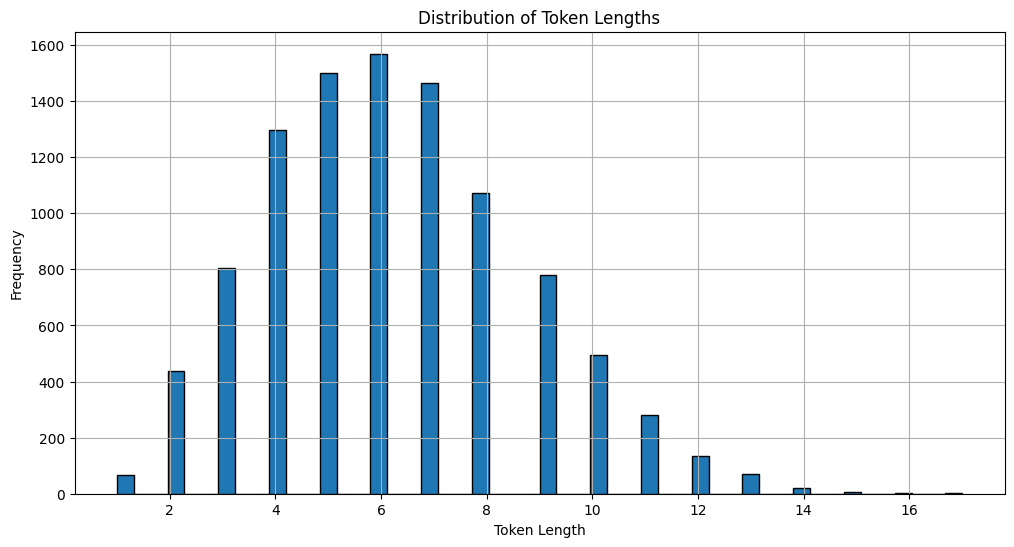

In [8]:
# 5. Token length analysis
token_lengths = [len(token) for token in vocab.keys()]

print("\n=== Token Length Analysis ===")
print(f"Minimum token length: {min(token_lengths)}")
print(f"Maximum token length: {max(token_lengths)}")
print(f"Average token length: {np.mean(token_lengths):.2f}")

# 6. Visualize token length distribution
plt.figure(figsize=(12, 6))
plt.hist(token_lengths, bins=50, edgecolor='black')
plt.title('Distribution of Token Lengths')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [9]:
# 7. Check for special characters or potential issues in tokens
print("\n=== Token Content Analysis ===")
special_char_tokens = [token for token in vocab.keys() if not token.isalnum()]
print(f"Number of tokens with special characters: {len(special_char_tokens)}")
if len(special_char_tokens) > 0:
    print("Sample of tokens with special characters:")
    for token in special_char_tokens[:10]:  # Show first 10 examples
        print(f"Token: {token}, Index: {vocab[token]}")

# 8. Check for consistency between vocab size and indices
print("\n=== Consistency Check ===")
expected_size = max_index + 1  # Assuming indices start from 0
print(f"Expected vocabulary size based on max index: {expected_size}")
print(f"Actual vocabulary size: {len(vocab)}")
print(f"Difference: {expected_size - len(vocab)}")

# 9. Memory usage analysis
import sys
vocab_memory = sys.getsizeof(vocab_dict)
print("\n=== Memory Usage ===")
print(f"Vocabulary dictionary size in memory: {vocab_memory / 1024:.2f} KB")


=== Token Content Analysis ===
Number of tokens with special characters: 211
Sample of tokens with special characters:
Token: <PAD>, Index: 0
Token: <UNK>, Index: 1
Token: ., Index: 3
Token: ,, Index: 5
Token: <BOS>, Index: 6
Token: <EOS>, Index: 7
Token: ?, Index: 19
Token: ", Index: 27
Token: *, Index: 34
Token: (, Index: 38

=== Consistency Check ===
Expected vocabulary size based on max index: 10001
Actual vocabulary size: 10000
Difference: 1

=== Memory Usage ===
Vocabulary dictionary size in memory: 0.18 KB


In [12]:
vocab

{'<PAD>': 0,
 '<UNK>': 1,
 '.': 3,
 'the': 4,
 ',': 5,
 '<BOS>': 6,
 '<EOS>': 7,
 'to': 8,
 'a': 9,
 'i': 10,
 'and': 11,
 'of': 12,
 'you': 13,
 'is': 14,
 'it': 15,
 'that': 16,
 'in': 17,
 'for': 18,
 '?': 19,
 'but': 20,
 'on': 21,
 'this': 22,
 'be': 23,
 'with': 24,
 'have': 25,
 'not': 26,
 '"': 27,
 'are': 28,
 'if': 29,
 'was': 30,
 'they': 31,
 'as': 32,
 'just': 33,
 '*': 34,
 'my': 35,
 'so': 36,
 'like': 37,
 '(': 38,
 '!': 39,
 'or': 40,
 'your': 41,
 'at': 42,
 'he': 43,
 ')': 44,
 'can': 45,
 "it's": 46,
 'what': 47,
 'all': 48,
 'do': 49,
 'get': 50,
 'would': 51,
 'about': 52,
 'me': 53,
 'one': 54,
 'from': 55,
 'more': 56,
 'an': 57,
 'people': 58,
 'out': 59,
 'no': 60,
 'up': 61,
 "don't": 62,
 'we': 63,
 'will': 64,
 '...': 65,
 'when': 66,
 'there': 67,
 'think': 68,
 "i'm": 69,
 'them': 70,
 '-': 71,
 'how': 72,
 'because': 73,
 'some': 74,
 'has': 75,
 ':': 76,
 'good': 77,
 'time': 78,
 'really': 79,
 'by': 80,
 '/': 81,
 'their': 82,
 'his': 83,
 'know': 84,